## Comparative Analysis of Clustering Algoriths

* In this notebook, I implemented three clustering algorithms: **K-Means**, **DBSCAN**, and **HDBSCAN**. Each algorithm is made from scratch using `NumPy` and results are visualized using `Matplotlib`. The goal is to apply these algorithms to a two-dimensional clustering dataset and analyze how each method groups data points based on its underlying principles. We'll also compare their results visually and quantitatively. 


### Importing libraries and functions

In [1]:
import pandas as pd
import matplotlib.pyplot as  plt
from utils import kmeans, dbscan, hdbscan, plot_clusters, silhouette_score

### Reading the 2-dimensional dataset

In [2]:
data = pd.read_csv("clustering_data.csv")

# Loading the values
X = data.values

data.head()

,x,y
0,262.354,90.171
1,58.571,357.793
2,210.552,263.524
3,156.131,260.007
4,135.543,388.240


In [11]:
data.describe()

,x,y
count,10000.000000,10000.00000
mean,324.955515,207.06300
std,187.826328,109.90693
min,-74.464000,-16.79300
25%,161.713500,104.68200
50%,312.400500,221.41450
75%,487.407000,295.06975
max,721.157000,454.97500


### Visualization of the raw dataset

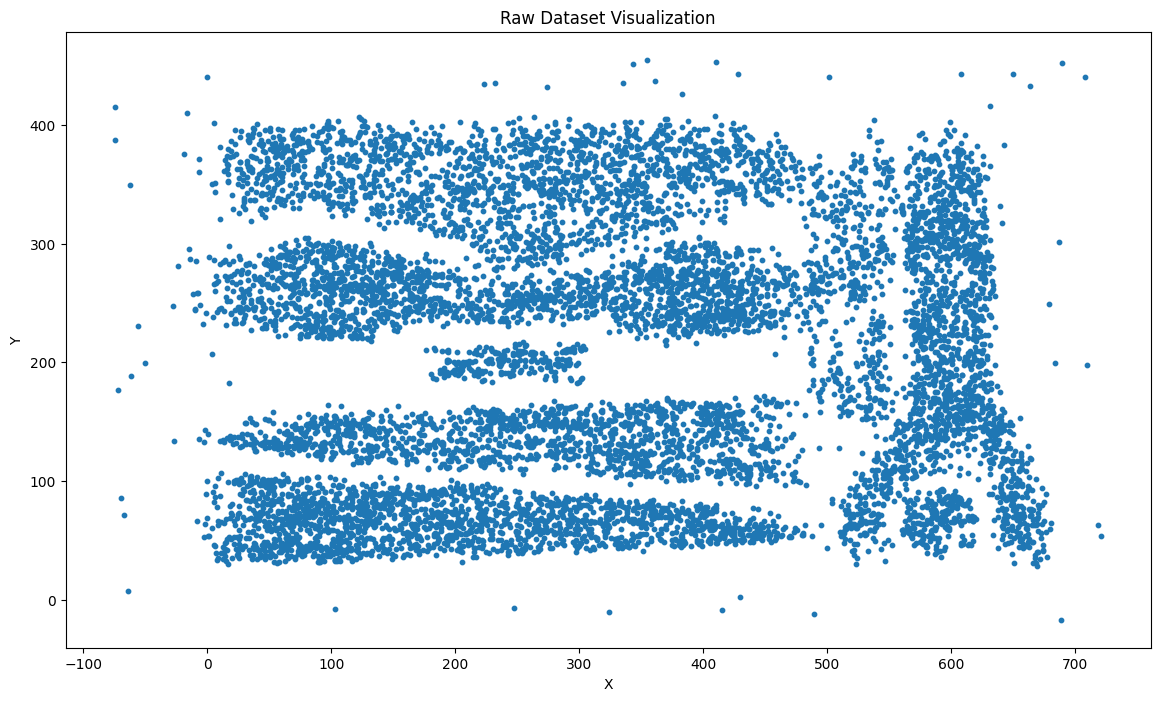

In [3]:
# Plot
plt.figure(figsize=(14, 8))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Raw Dataset Visualization")
plt.show()


* From the above plot, several observations can be made about the dataset.
    1. The data points span a wide range in both dimensions. Along the x-axis, the values extend from -74 to 721, while along the y-axis they range from -16 to 454. The exact values for the min and max values are found using `df.describe()`. This wide spatial distribution indicates that the dataset covers a large area in the feature space, making it well-suited for evaluating clustering algorithms under varied density and structural conditions.
    2. Visually, distinct cluster structures are already apparent. Human perception, in this case, acts as an intuitive clustering mechanism. By simple inspection, several meaningful groupings can be identified: two right-angled clusters that appear complementary and could nearly form a rectangle if placed closer together found at the bottom, an inverted “Y”-shaped structure on the right, two irregularly shaped clusters near the top and a small circular cluster near the center.
* The key question, however, is whether clustering algorithms-relying purely on mathematical definitions of distance and density-can accurately detect and separate these visually distinguishable structures.

* Let's now call each clustering algorithm from `utils.py` and train them on the dataset with specific parameters.

In [5]:
# K-Means Clustering
kmeans_labels = kmeans(X,k=5,max_iters=100)
# DBSCAN
dbscan_labels = dbscan(X,eps=10,min_pts=5)
# HDBSCAN
hdbscan_labels = hdbscan(X, min_samples=5, min_cluster_size=30)

## Results of the Algorithms

#### 1. K-Means Clustering

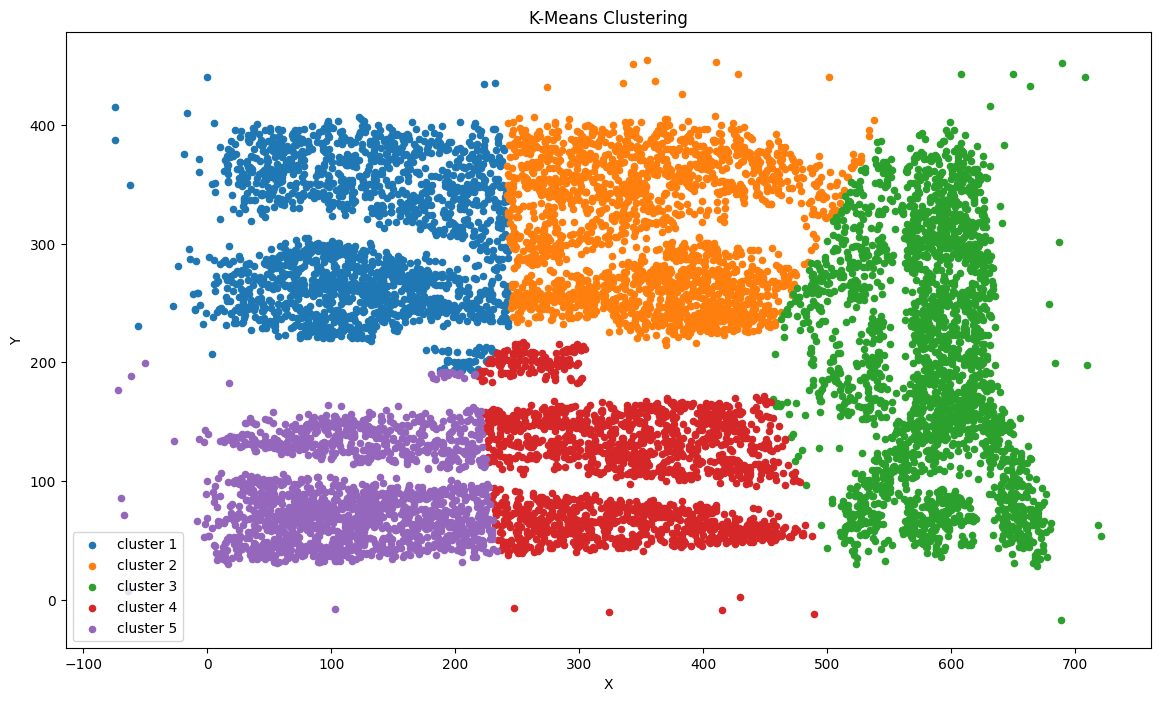

In [12]:
plot_clusters(X,kmeans_labels, "K-Means Clustering")

* **K-Means clustering** operates by first selecting `k` initial points from the dataset to serve as centroids. In our case, this initialization is reproducible rather than fully random because we set `np.random.seed(42)`. These initial centroids represent the starting positions of the clusters. The algorithm then computes the Euclidean distance between each data point and every centroid. Each point is assigned to the cluster whose centroid is closest to it. After all points are assigned, the algorithm recalculates each centroid as the mean of the points belonging to its cluster. This process of assignment and centroid recomputation is repeated for a fixed number of iterations (`max_iters`) or until convergence, meaning the centroids no longer change significantly.
* ***Observation***: The K-Means clustering algorithm gave the result shown in the above plot. As we can tell just by seeing, it didn't make the best clustering.  

* There are few problems with the clustering k-means made.
    1. k is set before we trained our algorithm. This almost makes the clustering pre-defined and makes it less accurate. If I set the k value to 15, the algorithm will try to falsely cluster 15 clusters, when in reality there aren't that much cluster in the dataset. This makes the choice of k critical and sometimes subjective.
    2. The random point selection is another thing that makes this algorithm less effective. If I changed the random access seed from 42 to any other point, it will make a new and different type of clustering. So, if it's not properly configured, k-means clustering can give different type of clusters with each run.
    3. K-Means is fundamentally a centroid-based algorithm that assigns points to clusters based solely on their proximity to a mean location. This approach assumes that clusters are roughly spherical and evenly sized. It struggles with clusters that are irregularly shaped, clusters with varying density and clusters with outliers. 

* Nonetheless, K-Means has several strengths. It is computationally efficient and scales well with increasing sample size. Its implementation is straightforward, and it typically produces clean, well-separated clusters when the underlying data structure is compact and approximately spherical.

#### 2. DBSCAN

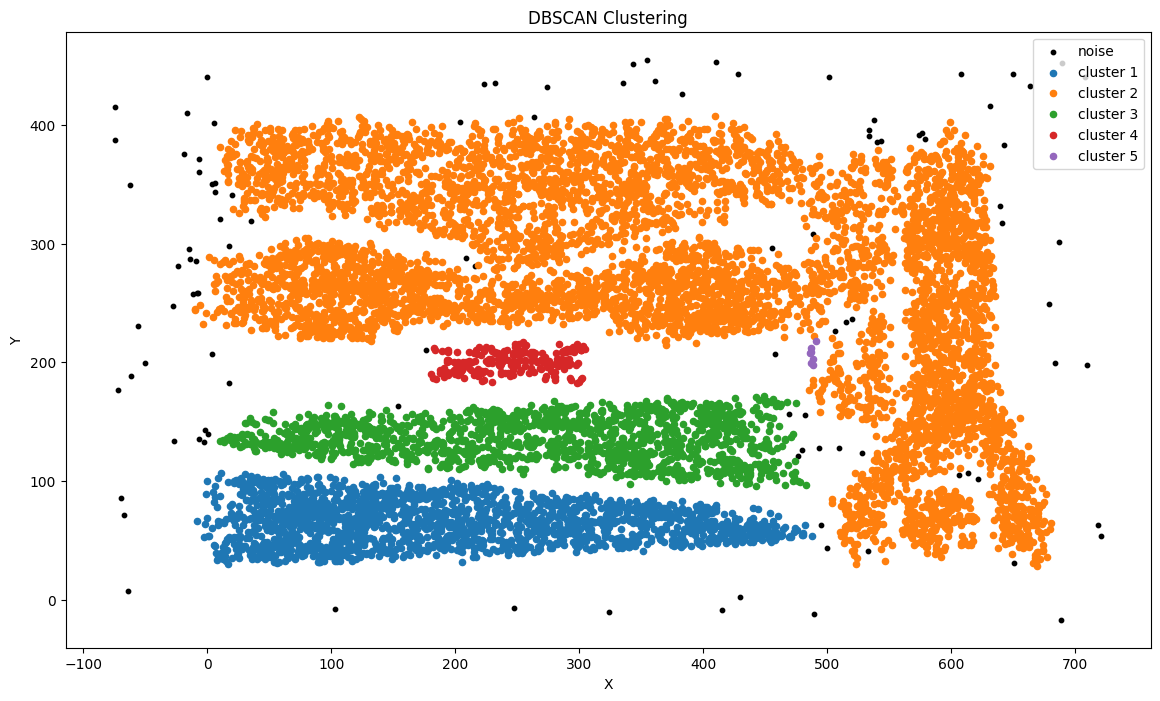

In [18]:
plot_clusters(X, dbscan_labels, "DBSCAN Clustering")

* **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** operates based on density rather than distance to a centroid. Instead of predefining the number of clusters, the algorithm relies on two parameters: `eps` (epsilon), which defines the radius of a neighborhood around a point, and `min_pts`, which specifies the minimum number of points required within that radius for a point to be considered a core point. Using these definition, the algorithm classifies each point as **core-point**, **border point** and **outlier**.
* ***Observation***: **DBSCAN** gave a better clustering, compared to k-means. It noticed density around certain areas and marked them as single cluster.

* Despite its strengths, several limitations of DBSCAN are noticeable:

    1. The performance of DBSCAN heavily depends on choosing appropriate values for `eps` and `min_pts`. If eps is too small, many points will be labeled as noise and clusters may fragment. If eps is too large, distinct clusters may merge into a single cluster. Selecting optimal parameters often requires experimentation.
    2. DBSCAN uses a single global eps value for the entire dataset. When clusters have significantly different densities, a single radius may not properly capture all structures. Dense clusters may be detected correctly while sparse clusters may be treated as noise, or vice versa.

* DBSCAN has several strong advantages. It does not require predefining the number of clusters and can detect arbitrarily shaped clusters (including non-linear structures). More importantly, it can detect outlier and mark them as noise, which is very crucial for our dataset and is also something k-means clustering can't do.


#### 3. HDBSCAN

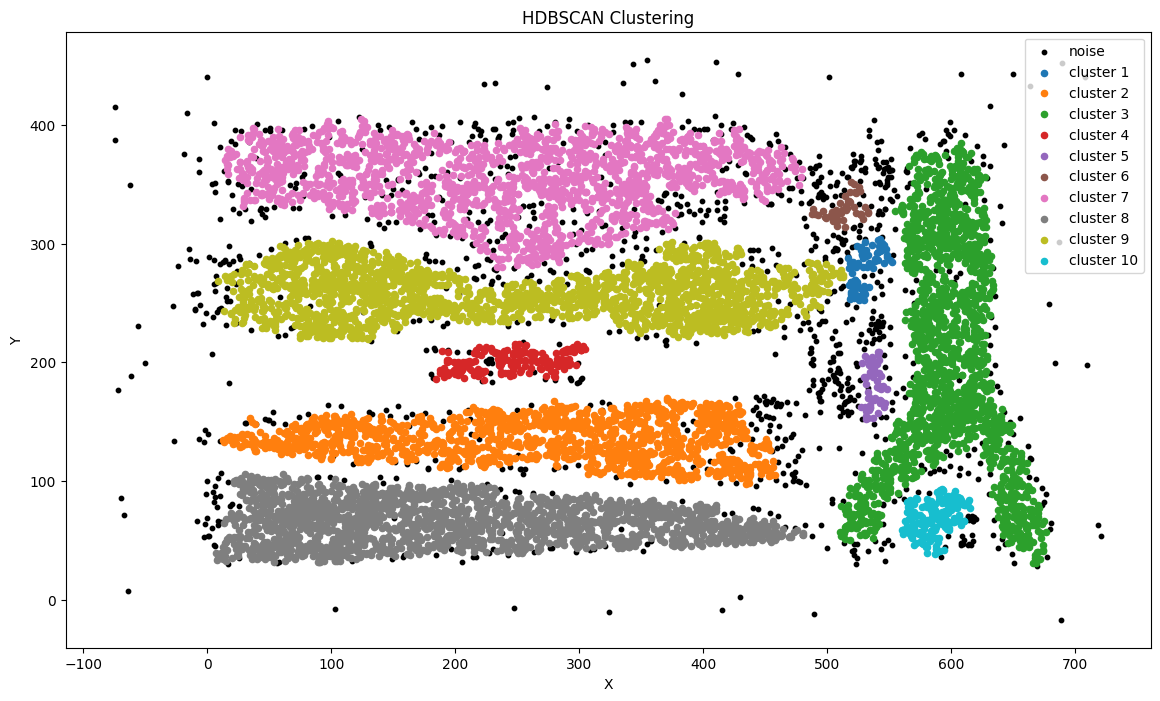

In [9]:
plot_clusters(X, hdbscan_labels, "HDBSCAN Clustering")

* **HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)** extends the idea of DBSCAN by introducing a ***hierarchical approach*** to density-based clustering. Instead of relying on a single global eps value, HDBSCAN analyzes the dataset assigned different eps value based on the density of data points. 

* ***Observation***: **HDBSCAN** produced the most accurate and visually coherent clustering result among the three algorithms. It successfully identified all of the major cluster structures that are clearly distinguishable. Unlike k-means, it correctly captured the irregular and non-linear shapes present in the dataset, assigning each meaningful structure to its own cluster.

* However, HDBSCAN also has limitations:
    1. Building the underlying concepts of HDBSCAN can be computationally expensive, especially when implemented from scratch without optimized data structures. For large datasets, this process can be significantly slower than K-Means or DBSCAN.
    2. Compared to K-Means and DBSCAN, HDBSCAN is conceptually and programmatically more complex. A full implementation requires careful handling of hierarchical structures and stability calculations.

* Nonetheless, HDBSCAN can detect clusters of varying densities, handle complex and irregular shapes, and automatically determine the effective number of clusters. Unlike DBSCAN, it adapts to local density differences rather than enforcing a single global density threshold. In datasets with heterogeneous cluster structures, HDBSCAN often produces more robust and meaningful clustering results.

#### Comparing the clustering results using **Silhouette Score**

In [6]:
print(f"The silhouette score for k means: {silhouette_score(X, kmeans_labels):.4f}")
print(f"The silhouette score for dbscan: {silhouette_score(X, dbscan_labels):.4f}")
print(f"The silhouette score for hdbscan: {silhouette_score(X, hdbscan_labels):.4f}")

The silhouette score for k means: 0.4455
The silhouette score for dbscan: -0.2781
The silhouette score for hdbscan: -0.0504


* The silhouette results indicate that **K-Means** (0.4455) achieved a moderately good clustering structure, while **DBSCAN** (-0.2781) and **HDBSCAN** (-0.0504) produced poor scores according to this metric.
* The reason the score favors K-Means is mainly due to the assumptions built into the silhouette metric itself. Silhouette tends to reward ***compact, convex, and well-separated (often spherical)*** clusters - which is exactly the type of structure K-Means is designed to produce. In contrast, DBSCAN and HDBSCAN identify ***irregular, non-convex, and density-based*** cluster shapes.